# Experiment 2: 2D Rhythmic DMP

This experiment develops a rhythmic DMP that learns cyclic motion from a
single demonstration cycle

Unlike discrete DMPs, the canonical system here is a phase oscillator
(linearly increasing phase), the basis functions are periodic
and the forcing term stays active throughout.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from Performance_measuring import test_dmp_performance

## Rhythmic DMP Function

This wraps the full  pipeline into a single fiunction. It takes a
single-cycle demonstration, lears the forcing term, then rolls out for several cycles, with invariance.

In [8]:
def dmp_rhythmic_2d(
    pos, dt, tau_demo,
    kp=150.0, kv=25.0,
    basis_num=40,
    newTau=3.0,                  # period of one cycle during rollout
    cycles=5,                    # how many cycles to generate
    center_shift=(0.0, 0.0),
    amplitude_scale=1.0,         # scales the forcing term to change orbit size

    eps=1e-12
):
    pos = np.asarray(pos, dtype=float)
    assert pos.ndim == 2 and pos.shape[0] == 2, "pos must be (2,T)"

    dim, T = pos.shape

    # derivatives from the demo
    vel = np.gradient(pos, axis=-1) / dt
    acc = np.gradient(vel, axis=-1) / dt

    # rhythmic centre (replaces 'goal' in discrete DMPs)
    y0     = np.mean(pos, axis=1)
    y0_new = y0 + np.asarray(center_shift, dtype=float).reshape(2,) # apply center shift to the rhythmic centre

    # periodic basis functions — centres evenly spaced around [0, 2*pi)
    Phi = np.zeros(basis_num)
    c   = np.zeros(basis_num)
    h   = np.zeros(basis_num)
    for i in range(basis_num):
        c[i] = 2*np.pi * i / basis_num
    h[:] = 2.0 * basis_num

    # learning 
    Phi_total = np.zeros((T, basis_num))
    force     = np.zeros((T, dim))

    omega = 2*np.pi / tau_demo
    phi   = 0.0

    for i in range(T):
        phi = phi + omega * dt

        addsum = 0.0
        for b in range(basis_num):
            Phi[b] = np.exp(h[b] * (np.cos(phi - c[b]) - 1.0))
            addsum += Phi[b]
        Phi = Phi / (addsum + eps)
        Phi_total[i, :] = Phi

        # target forcing term: f* = tau^2 * acc - kp*(y0 - pos) + tau * kv * vel
        force[i, :] = (tau_demo**2)*acc[:, i] - kp*(y0 - pos[:, i]) + tau_demo*kv*vel[:, i]
        
    # learn weights using linear regression
    W = np.matmul(np.linalg.pinv(Phi_total), force)

    # rollout for multiple cycles 
    tau_cycle = newTau
    tau_total = cycles * tau_cycle

    newLen = int(np.round(tau_total / dt))
    t_roll = np.linspace(0, tau_total, newLen, endpoint=False)

    DMP_pos = np.zeros((dim, newLen))
    DMP_vel = np.zeros((dim, newLen))
    DMP_acc = np.zeros((dim, newLen))

    DMP_pos[:, 0] = pos[:, 0]
    DMP_vel[:, 0] = vel[:, 0] * (tau_demo / tau_cycle)  # scale initial velocity to match new period

    omega_new = 2*np.pi / tau_cycle
    phi = 0.0

    for i in range(newLen - 1):
        phi = phi + omega_new * dt

        addsum = 0.0
        for b in range(basis_num):
            Phi[b] = np.exp(h[b] * (np.cos(phi - c[b]) - 1.0))
            addsum += Phi[b]

        newForce = np.matmul(Phi / (addsum + eps), W)  * amplitude_scale

        # spring-damper around the new rhythmic centre
        DMP_acc[:, i] = (kp*(y0_new - DMP_pos[:, i]) - tau_cycle*kv*DMP_vel[:, i] + newForce) / (tau_cycle**2)

        DMP_pos[:, i+1] = DMP_pos[:, i] + DMP_vel[:, i] * dt
        DMP_vel[:, i+1] = DMP_vel[:, i] + DMP_acc[:, i] * dt

    return DMP_pos, DMP_vel, DMP_acc, W, y0_new, t_roll

## Test 1


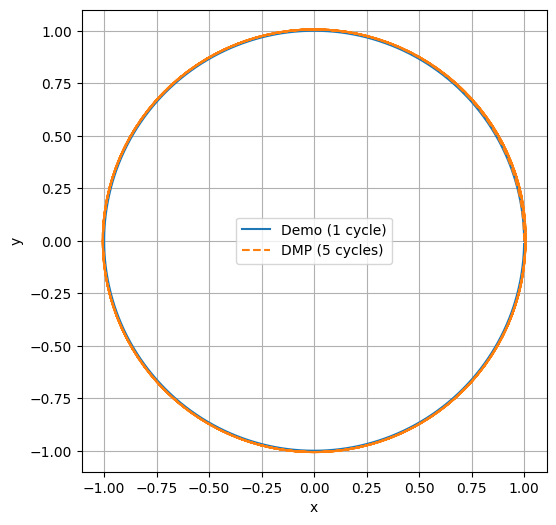

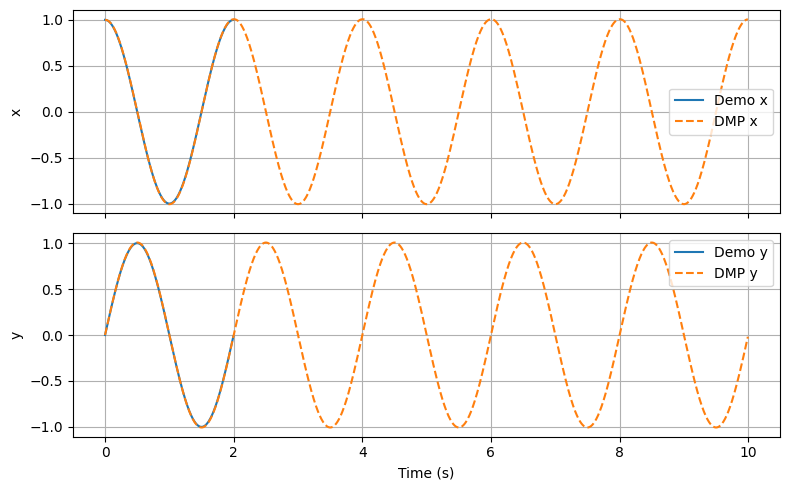

In [9]:

import numpy as np
import matplotlib.pyplot as plt

dt = 0.005
dim = 2

tau = 2.0                               # period (seconds) for one full cycle
T = int(np.round(tau / dt))
t_demo = np.linspace(0, tau, T, endpoint=False)

A = 1.0

pos_circle = np.zeros((2, T))
pos_circle[0, :] = A * np.cos(2*np.pi * t_demo / tau)
pos_circle[1, :] = A * np.sin(2*np.pi * t_demo / tau)

DMP_pos_c, DMP_vel_c, DMP_acc_c, W_c, y0_c, t_roll_c = dmp_rhythmic_2d(
    pos_circle, dt, tau,
    kp=150.0, kv=25.0, basis_num=40,
    newTau=2,
    cycles=5,
)

plt.figure(figsize=(6, 6))
plt.plot(pos_circle[0], pos_circle[1], label="Demo (1 cycle)")
plt.plot(DMP_pos_c[0], DMP_pos_c[1], label="DMP (5 cycles)", linestyle='--')
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.xlabel("x"); plt.ylabel("y")
plt.show()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax1.plot(t_demo, pos_circle[0], label="Demo x")
ax1.plot(t_roll_c, DMP_pos_c[0], label="DMP x", linestyle='--')
ax1.set_ylabel("x"); ax1.legend(); ax1.grid(True)

ax2.plot(t_demo, pos_circle[1], label="Demo y")
ax2.plot(t_roll_c, DMP_pos_c[1], label="DMP y", linestyle='--')
ax2.set_xlabel("Time (s)"); ax2.set_ylabel("y"); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

## Test 2


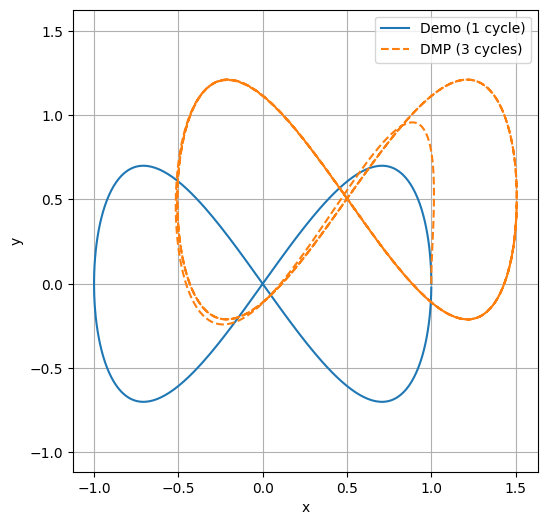

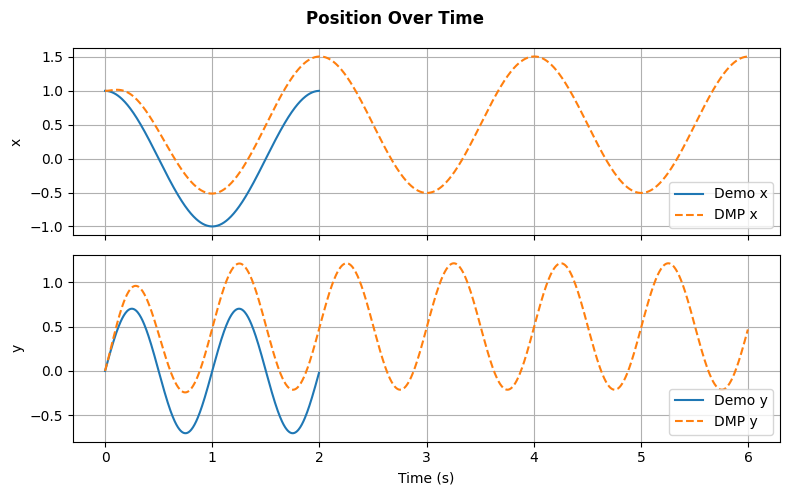

In [10]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.005
tau_demo = 2.0
T = int(np.round(tau_demo/dt))
t_demo = np.linspace(0, tau_demo, T, endpoint=False)

A = 1.0

pos_liss = np.zeros((2, T))
pos_liss[0, :] = A * np.cos(2*np.pi * 1 * t_demo / tau_demo)
pos_liss[1, :] = 0.7 * A * np.sin(2*np.pi * 2 * t_demo / tau_demo)

DMP_pos_l, DMP_vel_l, DMP_acc_l, W_l, y0_l, t_roll_l = dmp_rhythmic_2d(
    pos_liss, dt, tau_demo,
    kp=150.0, kv=25.0, basis_num=40,
    newTau=tau_demo,
    cycles=3,
    center_shift=(0.5, 0.5)
)

plt.figure(figsize=(6, 6))
plt.plot(pos_liss[0], pos_liss[1], label="Demo (1 cycle)" )
plt.plot(DMP_pos_l[0], DMP_pos_l[1], label="DMP (3 cycles)", linestyle='--')
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.xlabel("x"); plt.ylabel("y")
plt.show()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax1.plot(t_demo, pos_liss[0], label="Demo x")
ax1.plot(t_roll_l, DMP_pos_l[0], label="DMP x", linestyle='--')
ax1.set_ylabel("x"); ax1.legend(); ax1.grid(True)

ax2.plot(t_demo, pos_liss[1], label="Demo y")
ax2.plot(t_roll_l, DMP_pos_l[1], label="DMP y", linestyle='--')
ax2.set_xlabel("Time (s)"); ax2.set_ylabel("y"); ax2.legend(); ax2.grid(True)

fig.suptitle("Position Over Time", fontweight='bold')
plt.tight_layout()
plt.show()

## Test 3


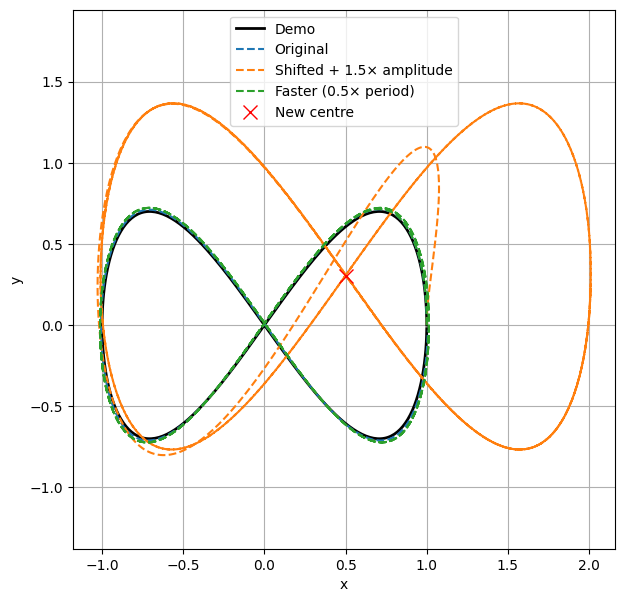

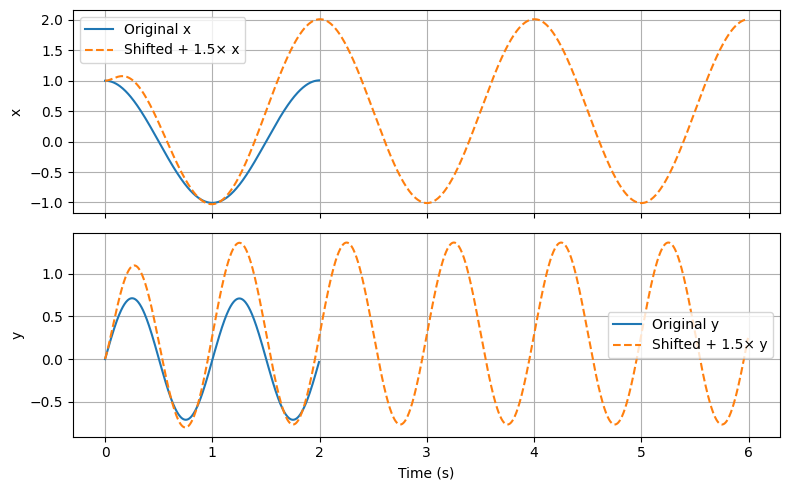

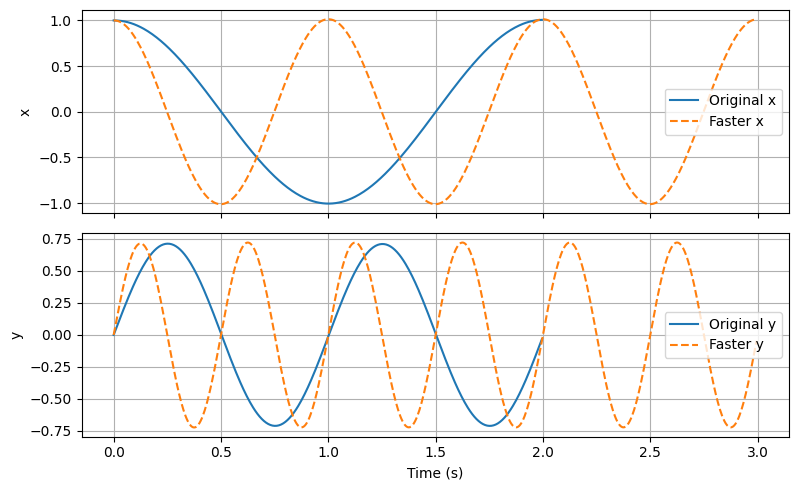

In [11]:
# original reproduction (baseline for comparison)
DMP_orig, _, _, _, _, t_orig = dmp_rhythmic_2d(
    pos_liss, dt, tau_demo,
    newTau=tau_demo, cycles=1,
)

# case 1: shifted centre (+0.5, +0.3) + amplitude 1.5x
DMP_shifted, _, _, _, y0_shifted, t_shifted = dmp_rhythmic_2d(
    pos_liss, dt, tau_demo,
    newTau=tau_demo, cycles=3,
    center_shift=(0.5, 0.3),
    amplitude_scale=1.5,
)

# case 2: faster period (half the demo period)
DMP_fast, _, _, _, _, t_fast = dmp_rhythmic_2d(
    pos_liss, dt, tau_demo,
    newTau=tau_demo / 2, cycles=3,
)

# --- XY overlay (main invariance figure) ---
plt.figure(figsize=(7, 7))
plt.plot(pos_liss[0], pos_liss[1], 'k-', linewidth=2, label="Demo")
plt.plot(DMP_orig[0], DMP_orig[1], label="Original", linestyle='--')
plt.plot(DMP_shifted[0], DMP_shifted[1], label="Shifted + 1.5× amplitude", linestyle='--')
plt.plot(DMP_fast[0], DMP_fast[1], label="Faster (0.5× period)", linestyle='--')
plt.plot(y0_shifted[0], y0_shifted[1], 'rx', markersize=10, label="New centre")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.xlabel("x"); plt.ylabel("y")
plt.show()

# shifted + amplitude change
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax1.plot(t_orig, DMP_orig[0], label="Original x")
ax1.plot(t_shifted, DMP_shifted[0], label="Shifted + 1.5× x", linestyle='--')
ax1.set_ylabel("x"); ax1.legend(); ax1.grid(True)

ax2.plot(t_orig, DMP_orig[1], label="Original y")
ax2.plot(t_shifted, DMP_shifted[1], label="Shifted + 1.5× y", linestyle='--')
ax2.set_xlabel("Time (s)"); ax2.set_ylabel("y"); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

# period scaling
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax1.plot(t_orig, DMP_orig[0], label="Original x")
ax1.plot(t_fast, DMP_fast[0], label="Faster x", linestyle='--')
ax1.set_ylabel("x"); ax1.legend(); ax1.grid(True)

ax2.plot(t_orig, DMP_orig[1], label="Original y")
ax2.plot(t_fast, DMP_fast[1], label="Faster y", linestyle='--')
ax2.set_xlabel("Time (s)"); ax2.set_ylabel("y"); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

## Performance Evaluation

The DMP rollouts are longer than the demos (multi-cycle), so we compare the
first cycle of each rollout against the original demonstration.

In [12]:
def first_cycle(DMP_path, demo_len):
    return DMP_path[:, :demo_len]

print("Circle")
_, metrics_circle = test_dmp_performance(pos_circle, first_cycle(DMP_pos_c, T))
for key, value in metrics_circle.items():
    print(f"  {key}: {value}")

print()
print("Lissajous:")
_, metrics_liss = test_dmp_performance(pos_liss, first_cycle(DMP_pos_l, T))
for key, value in metrics_liss.items():
    print(f"  {key}: {value}")

print()
print("Lissajous with invariance tests:")
_, metrics_liss = test_dmp_performance(pos_liss, first_cycle(DMP_orig, T))
print("Original:")
for key, value in metrics_liss.items(): 
    print(f"  {key}: {value}")

Circle
  final_goal_error: 0.007327477431739973
  RMS_tracking_error: 0.0068136231497269995
  min_distance_each_obstacle: []
  min_distance_overall: None
  original_path_length: 6.267412909191645
  DMP_path_length: 6.301492172560185

Lissajous:
  final_goal_error: 0.7032888571624389
  RMS_tracking_error: 0.6199186551046709
  min_distance_each_obstacle: []
  min_distance_overall: None
  original_path_length: 7.340889577694627
  DMP_path_length: 7.234668238526687

Lissajous with invariance tests:
Original:
  final_goal_error: 0.01349307192244258
  RMS_tracking_error: 0.012216809606230715
  min_distance_each_obstacle: []
  min_distance_overall: None
  original_path_length: 7.340889577694627
  DMP_path_length: 7.419930550593511
